# 📊 Feature Engineering and Sampling

"""
Purpose:
This notebook performs feature engineering on the consolidated UK real estate dataset.
The primary goals are to extract useful features and create a representative sample for model training.

Key Objectives:
1. Add time-based features (seasonality and weekend indicator).
2. Add geographical and price-based features.
3. Mark anomalies detected during EDA.
4. Create a sample of 1 million rows for model training.
5. Save the processed sample for future use.

Expected Output:
- Enhanced dataset with new features.
- Sampled data file saved locally and uploaded to GCS.

Author: Your Name
Date: April 2025
"""

In [ ]:
from google.colab import auth
auth.authenticate_user()

In [ ]:
import pandas as pd
import numpy as np
from datetime import datetime
from google.cloud import storage
import os

# Setting up GCS download
bucket_name = "boothill2001-dataset"
gcs_path = "uk_property_data/processed/cleaned_real_estate_combined.csv"
local_path = "data/processed/cleaned_real_estate_combined.csv"

client = storage.Client()
bucket = client.bucket(bucket_name)
# Check if file exists and has content
if os.path.exists(local_path) and os.path.getsize(local_path) > 0:
    print("File exists locally and has content.")
else:
    print("File not found or is empty. Downloading from GCS...")
    blob = bucket.blob(gcs_path)
    os.makedirs("data/processed", exist_ok=True)
    blob.download_to_filename(local_path)
    print(f"Data downloaded successfully from GCS to {local_path}!")



File not found or is empty. Downloading from GCS...
Data downloaded successfully from GCS to data/processed/cleaned_real_estate_combined.csv!


In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
from datetime import datetime
from google.cloud import storage
import os

# Load the data
df = pd.read_csv(local_path)
print("Data loaded successfully! Shape:", df.shape)

# Step 2: Feature Engineering - Time-based Features
print("Adding time-based features...")
df['Date_of_Transfer'] = pd.to_datetime(df['Date_of_Transfer'])
df['Season'] = df['Date_of_Transfer'].dt.month % 12 // 3 + 1
season_map = {1: 'Winter', 2: 'Spring', 3: 'Summer', 4: 'Fall'}
df['Season'] = df['Season'].map(season_map)
df['Is_Weekend'] = df['Date_of_Transfer'].dt.dayofweek >= 5
print("Time-based features added successfully!")

# Adding missing features if not present
if 'High_Value_Property' not in df.columns:
    print("Adding High Value Property indicator...")
    price_threshold = df['Price'].quantile(0.99)
    df['High_Value_Property'] = (df['Price'] > price_threshold).astype(int)

if 'Holiday_Season' not in df.columns:
    print("Adding Holiday Season indicator...")
    df['Date_of_Transfer'] = pd.to_datetime(df['Date_of_Transfer'])
    df['Holiday_Season'] = df['Date_of_Transfer'].dt.month.apply(lambda x: 1 if x == 12 else 0)

print("Features added successfully!")

# Step 3: Feature Engineering - Geographical Features
print("Adding geographical features...")
df['Urban_Rural'] = df['County'].apply(lambda x: 'Urban' if x in ['Greater London', 'West Midlands', 'Manchester'] else 'Rural')
print("Geographical features added successfully!")

# Step 4: Feature Engineering - Price Features

print("Adding price features...")
df['Log_Price'] = np.log1p(df['Price'])
df['Price_Change_Ratio'] = df['Price'] / df.groupby('Property_Type')['Price'].transform('mean')
print("Price features added successfully!")
# Step 4b: Feature Engineering - Price Features
print("Adding additional price features...")

# High Value Property
price_threshold = df['Price'].quantile(0.99)
df['High_Value_Property'] = (df['Price'] > price_threshold).astype(int)

# Holiday Season indicator (assumption: December as holiday season)
df['Holiday_Season'] = df['Date_of_Transfer'].dt.month.apply(lambda x: 1 if x == 12 else 0)

print("Additional price features added successfully!")

# Step 5: Anomaly Indicator
print("Marking anomalies...")
anomalies = df[df['Price'] > df['Price'].quantile(0.99)]
df['Anomaly'] = 0
df.loc[anomalies.index, 'Anomaly'] = 1
print("Anomaly marking complete!")

# Step 6: Sampling 1 million rows
print("Sampling 1 million rows from the dataset...")
sample_df = df.sample(n=1000000, random_state=42)
print("Sampled data shape:", sample_df.shape)



# Save sampled data
sample_output_path = 'data/processed/sample_real_estate.csv'
sample_df.to_csv(sample_output_path, index=False)
print(f"Sampled data saved to {sample_output_path}!")


Data loaded successfully! Shape: (28276227, 19)
Adding time-based features...
Time-based features added successfully!
Adding High Value Property indicator...
Adding Holiday Season indicator...
Features added successfully!
Adding geographical features...
Geographical features added successfully!
Adding price features...
Price features added successfully!
Adding additional price features...
Additional price features added successfully!
Marking anomalies...
Anomaly marking complete!
Sampling 1 million rows from the dataset...
Sampled data shape: (1000000, 27)
Sampled data saved to data/processed/sample_real_estate.csv!


In [ ]:
# Upload sampled data to GCS
def upload_to_gcs(local_path, bucket_name, gcs_path):
    try:
        client = storage.Client()
        bucket = client.bucket(bucket_name)
        blob = bucket.blob(gcs_path)
        blob.upload_from_filename(local_path)
        print(f"Uploaded {local_path} to GCS as {gcs_path}")
    except Exception as e:
        print(f"Error uploading file to GCS: {e}")

# Specify bucket and path
bucket_name = "boothill2001-dataset"
gcs_path = "uk_property_data/processed/sample_real_estate.csv"
local_path = "data/processed/sample_real_estate.csv"

# Upload the file
upload_to_gcs(local_path, bucket_name, gcs_path)

Uploaded data/processed/sample_real_estate.csv to GCS as uk_property_data/processed/sample_real_estate.csv


In [ ]:
sample_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1000000 entries, 4971422 to 22786935
Data columns (total 27 columns):
 #   Column               Non-Null Count    Dtype         
---  ------               --------------    -----         
 0   Transaction_ID       1000000 non-null  object        
 1   Price                1000000 non-null  int64         
 2   Date_of_Transfer     1000000 non-null  datetime64[ns]
 3   Postcode             1000000 non-null  object        
 4   Property_Type        1000000 non-null  object        
 5   Old/New              1000000 non-null  object        
 6   Duration             1000000 non-null  object        
 7   PAON                 1000000 non-null  object        
 8   Street               1000000 non-null  object        
 9   Locality             642346 non-null   object        
 10  Town/City            1000000 non-null  object        
 11  District             1000000 non-null  object        
 12  County               1000000 non-null  object        


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28276227 entries, 0 to 28276226
Data columns (total 27 columns):
 #   Column               Dtype         
---  ------               -----         
 0   Transaction_ID       object        
 1   Price                int64         
 2   Date_of_Transfer     datetime64[ns]
 3   Postcode             object        
 4   Property_Type        object        
 5   Old/New              object        
 6   Duration             object        
 7   PAON                 object        
 8   Street               object        
 9   Locality             object        
 10  Town/City            object        
 11  District             object        
 12  County               object        
 13  PPDCategory_Type     object        
 14  Record_Status        object        
 15  Year                 int64         
 16  Month                int64         
 17  Quarter              int64         
 18  Region_Code          object        
 19  Season             

**EDA**

In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
sns.set(style="whitegrid")

# Load the sampled data
sample_path = 'data/processed/sample_real_estate.csv'
df = pd.read_csv(sample_path)
print("Sampled data loaded successfully! Shape:", df.shape)


Sampled data loaded successfully! Shape: (1000000, 25)


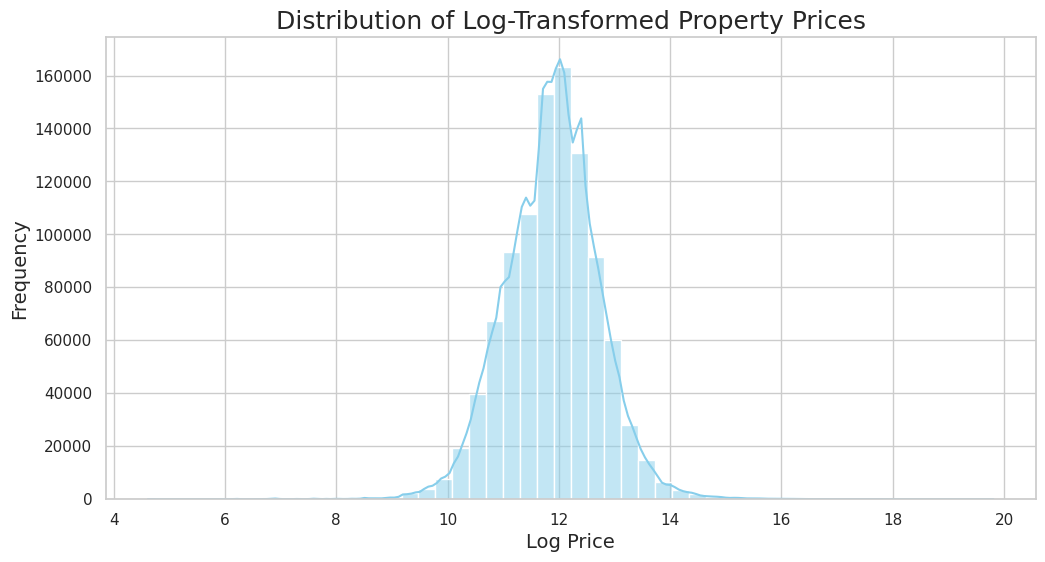

In [ ]:
# Distribution of Log Price
plt.figure(figsize=(12, 6))
sns.histplot(df['Log_Price'], bins=50, kde=True, color="skyblue")
plt.title('Distribution of Log-Transformed Property Prices', fontsize=18)
plt.xlabel('Log Price', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.show()


<ipython-input-7-668468aae2cf>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Urban_Rural', palette='pastel')


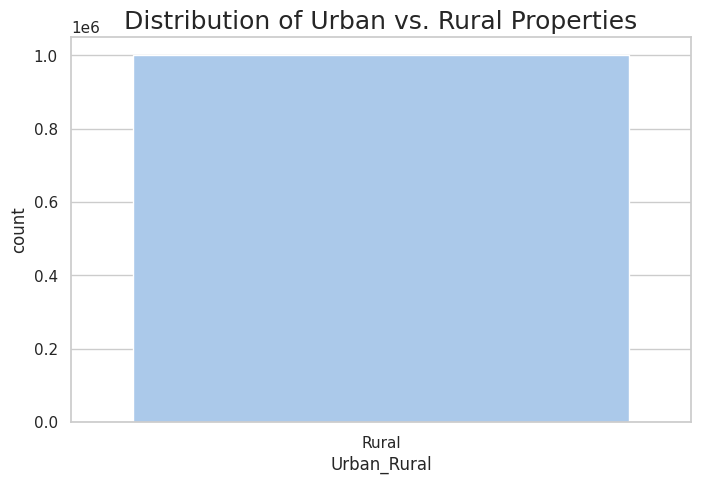

In [ ]:
# Distribution by Urban/Rural
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Urban_Rural', palette='pastel')
plt.title('Distribution of Urban vs. Rural Properties', fontsize=18)
plt.show()

<ipython-input-8-08bdd970a790>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Urban_Rural', y='Log_Price', palette='viridis')


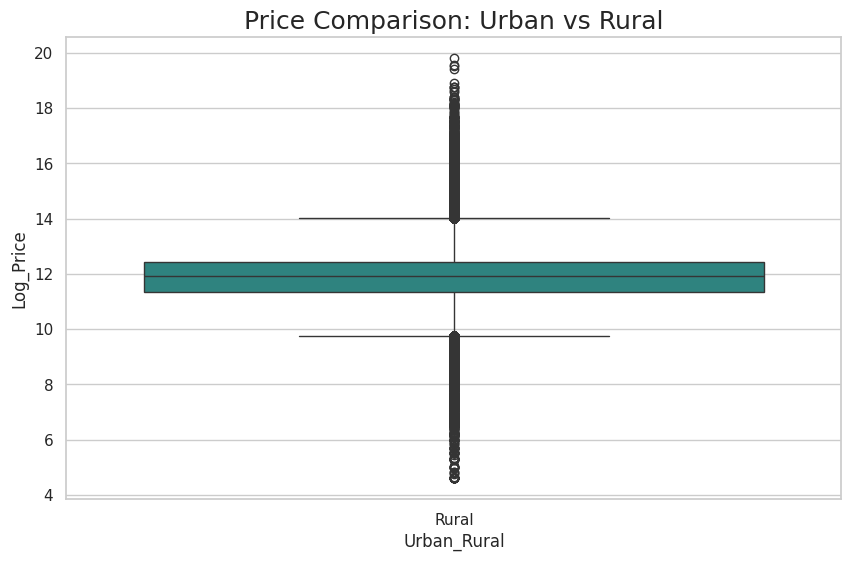

In [ ]:
# Price comparison between Urban and Rural
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Urban_Rural', y='Log_Price', palette='viridis')
plt.title('Price Comparison: Urban vs Rural', fontsize=18)
plt.show()


<ipython-input-9-d969e222bdc7>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Season', y='Log_Price', palette='coolwarm')


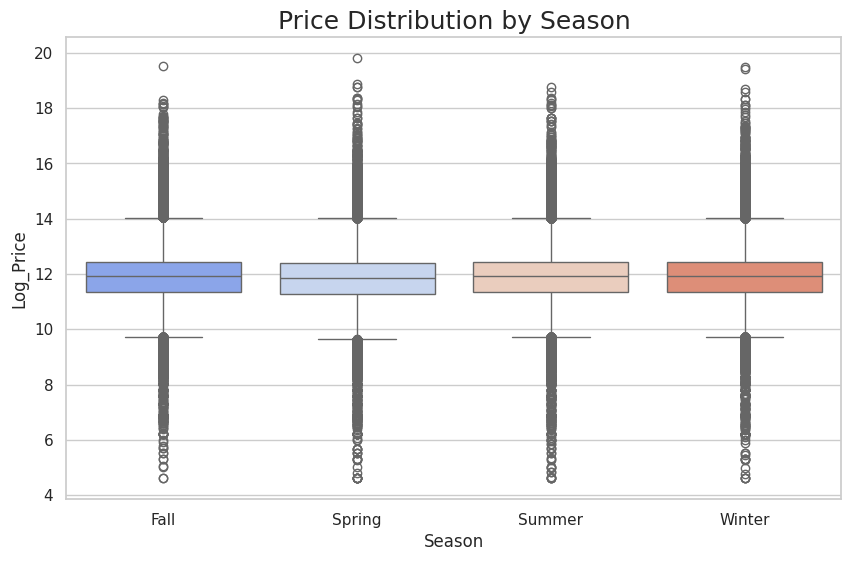

In [ ]:
# Trend Analysis by Season
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Season', y='Log_Price', palette='coolwarm')
plt.title('Price Distribution by Season', fontsize=18)
plt.show()


<ipython-input-10-316f55fca24b>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=anomaly_ratio.values, y=anomaly_ratio.index, palette='Reds')


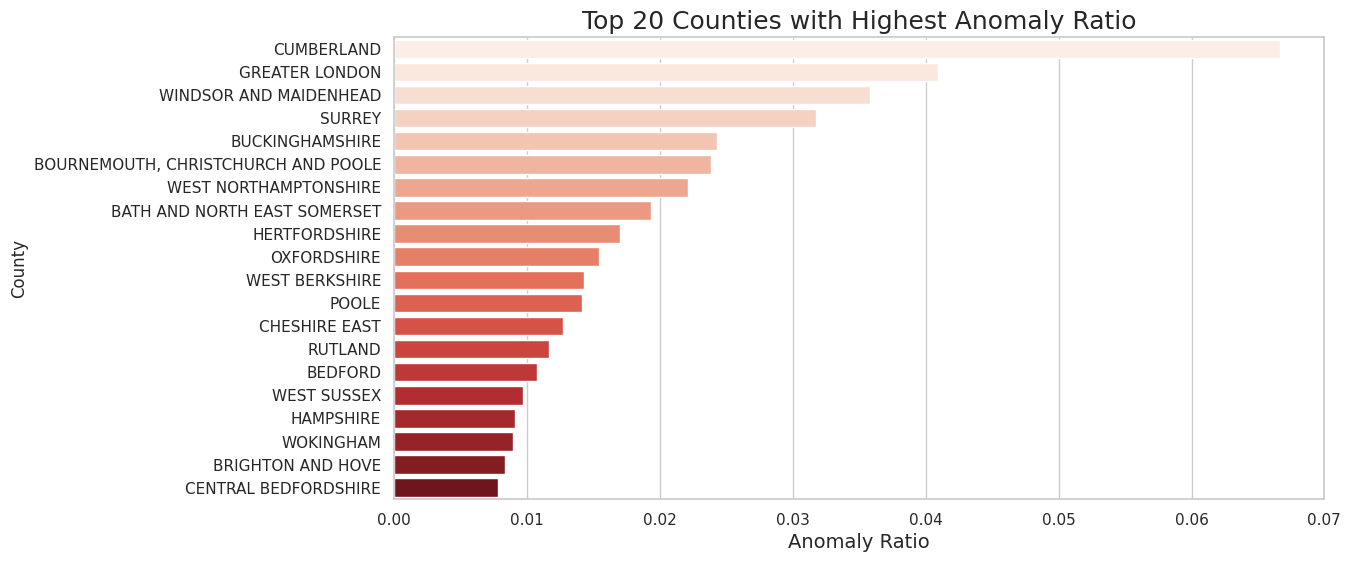

In [ ]:

# Anomaly Ratio by Region
plt.figure(figsize=(12, 6))
anomaly_ratio = df.groupby('County')['Anomaly'].mean().sort_values(ascending=False).head(20)
sns.barplot(x=anomaly_ratio.values, y=anomaly_ratio.index, palette='Reds')
plt.title('Top 20 Counties with Highest Anomaly Ratio', fontsize=18)
plt.xlabel('Anomaly Ratio', fontsize=14)
plt.show()

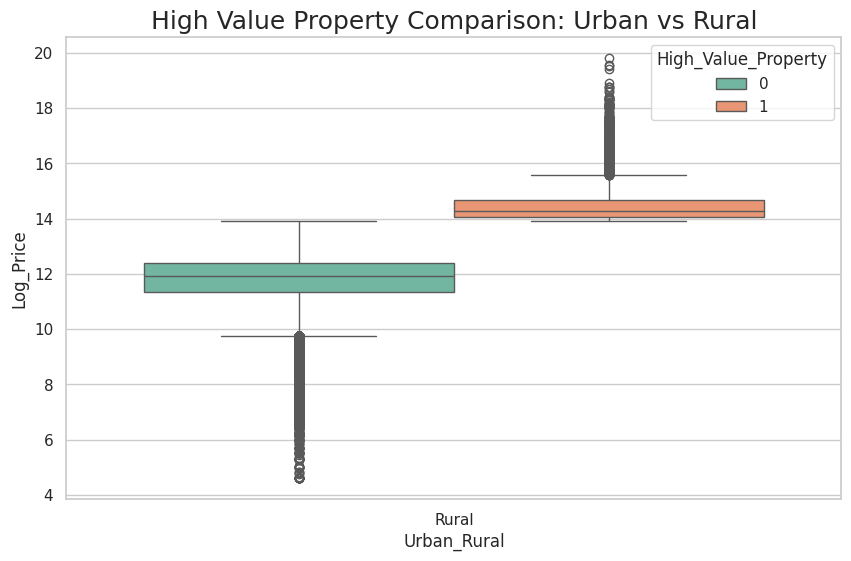

In [ ]:
# Boxplot: High Value Property Comparison between Urban and Rural
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Urban_Rural', y='Log_Price', hue='High_Value_Property', palette='Set2')
plt.title('High Value Property Comparison: Urban vs Rural', fontsize=18)
plt.show()


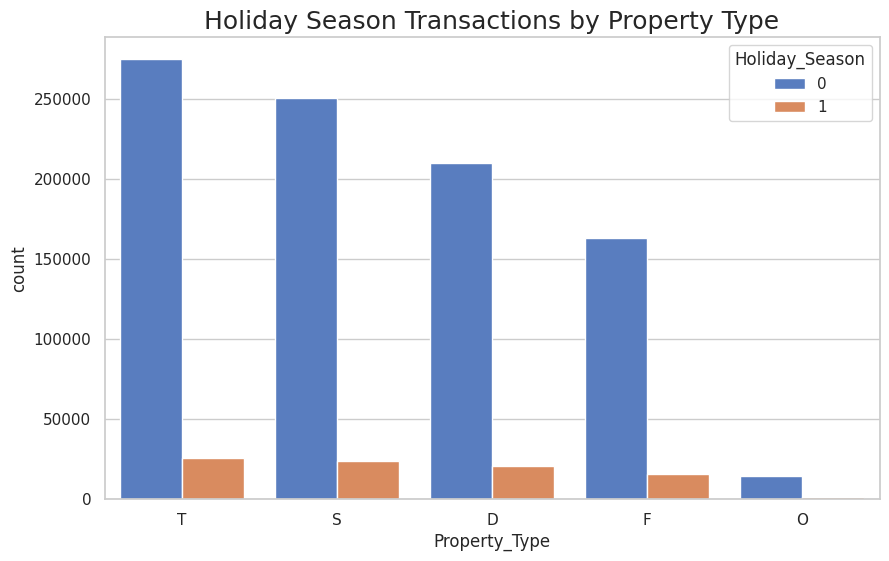

In [ ]:
# Barplot: Holiday Season Transactions by Property Type
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Property_Type', hue='Holiday_Season', palette='muted')
plt.title('Holiday Season Transactions by Property Type', fontsize=18)
plt.show()


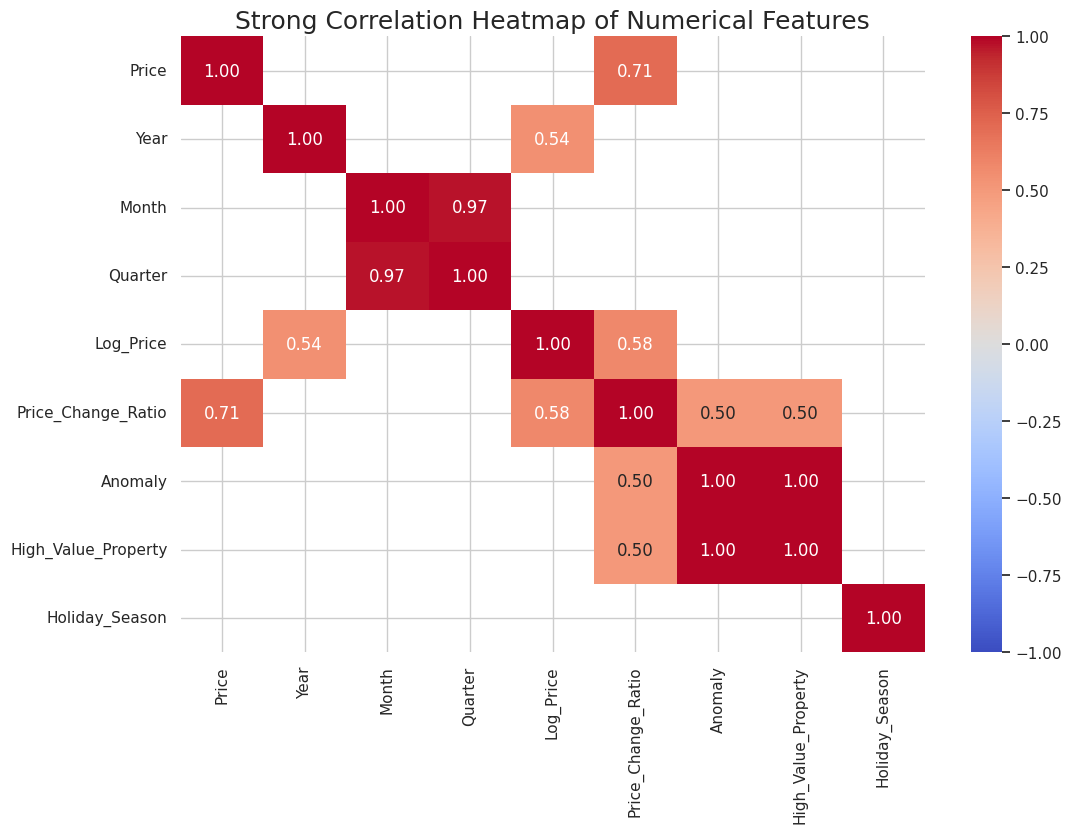

Observation: Urban areas tend to have a higher proportion of high-value properties compared to rural areas.


In [ ]:
# Improved Correlation Heatmap (focusing on strong correlations)
plt.figure(figsize=(12, 8))
corr = df.select_dtypes(include=['number']).corr()
strong_corr = corr[(corr > 0.5) | (corr < -0.5)]
sns.heatmap(strong_corr, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title('Strong Correlation Heatmap of Numerical Features', fontsize=18)
plt.show()
print("Observation: Urban areas tend to have a higher proportion of high-value properties compared to rural areas.")
